# Análisis de datos - TP Final

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import kagglehub
from scipy import stats as st
from scipy.stats import describe

## Descargamos dataset

In [89]:
# Download latest version
path = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

print("Path to dataset files:", path)

Path to dataset files: /home/jbmild/.cache/kagglehub/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/versions/874


## Cargamos el dataframe

In [90]:
df = pd.read_csv(path + "/TMDB_movie_dataset_v11.csv", na_values='sin especificar', encoding='ISO-8859-1')
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [91]:
df.describe()


,id,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.385673e+06,1.385673e+06,1.385673e+06,1.385673e+06,1.385673e+06,1.385673e+06,1.385673e+06
mean,8.806467e+05,1.587308e+00,1.548470e+01,6.254981e+05,4.435824e+01,2.395768e+05,1.035429e+00
std,4.679810e+05,2.876144e+00,2.885633e+02,1.922868e+07,6.077827e+01,5.102742e+06,6.886053e+00
min,2.000000e+00,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,4.848560e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e-01
50%,8.966730e+05,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,0.000000e+00,6.000000e-01
75%,1.291558e+06,2.000000e+00,1.000000e+00,0.000000e+00,8.500000e+01,0.000000e+00,7.310000e-01
max,1.650939e+06,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03


In [92]:
df.shape

(1385673, 24)

## Analisis de datos nulos

In [93]:
# Contar la proporción de valores nulos en cada columna
df.isna().sum()  

id                            0
title                        18
vote_average                  0
vote_count                    0
status                        0
release_date             298516
revenue                       0
runtime                       0
adult                         0
backdrop_path           1038785
budget                        0
homepage                1242734
imdb_id                  724787
original_language             0
original_title               18
overview                 315157
popularity                    0
poster_path              485861
tagline                 1192745
genres                   603142
production_companies     791600
production_countries     664282
spoken_languages         638052
keywords                1039965
dtype: int64

In [94]:
# Calcular la proporción de valores nulos en cada columna
df.isna().mean().round(4)*100

id                       0.00
title                    0.00
vote_average             0.00
vote_count               0.00
status                   0.00
release_date            21.54
revenue                  0.00
runtime                  0.00
adult                    0.00
backdrop_path           74.97
budget                   0.00
homepage                89.68
imdb_id                 52.31
original_language        0.00
original_title           0.00
overview                22.74
popularity               0.00
poster_path             35.06
tagline                 86.08
genres                  43.53
production_companies    57.13
production_countries    47.94
spoken_languages        46.05
keywords                75.05
dtype: float64

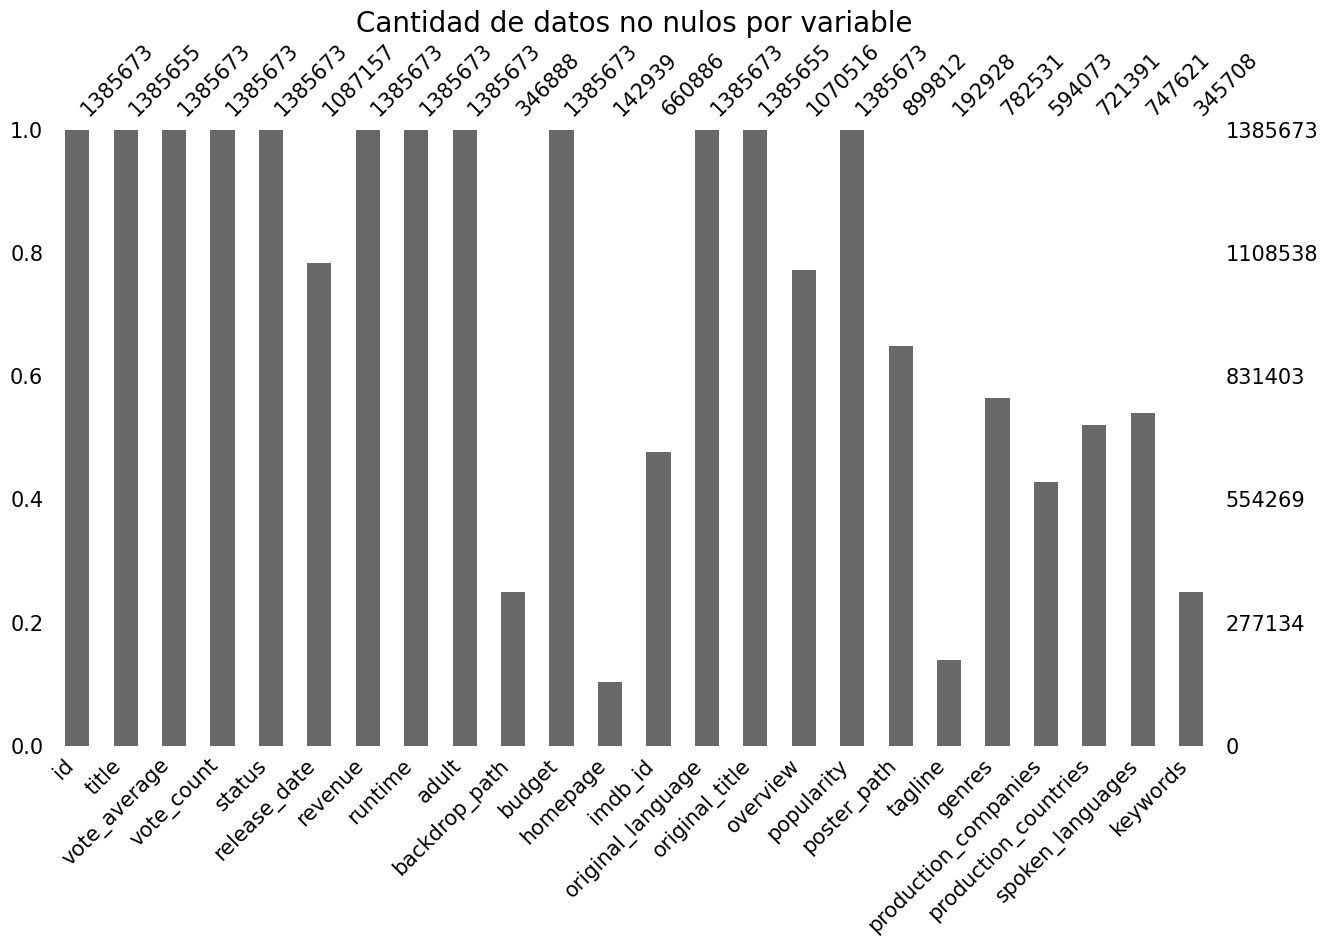

In [95]:
msno.bar(df, fontsize=15, figsize=(15,8))
plt.title("Cantidad de datos no nulos por variable", fontsize=20)
plt.show()

<Axes: >

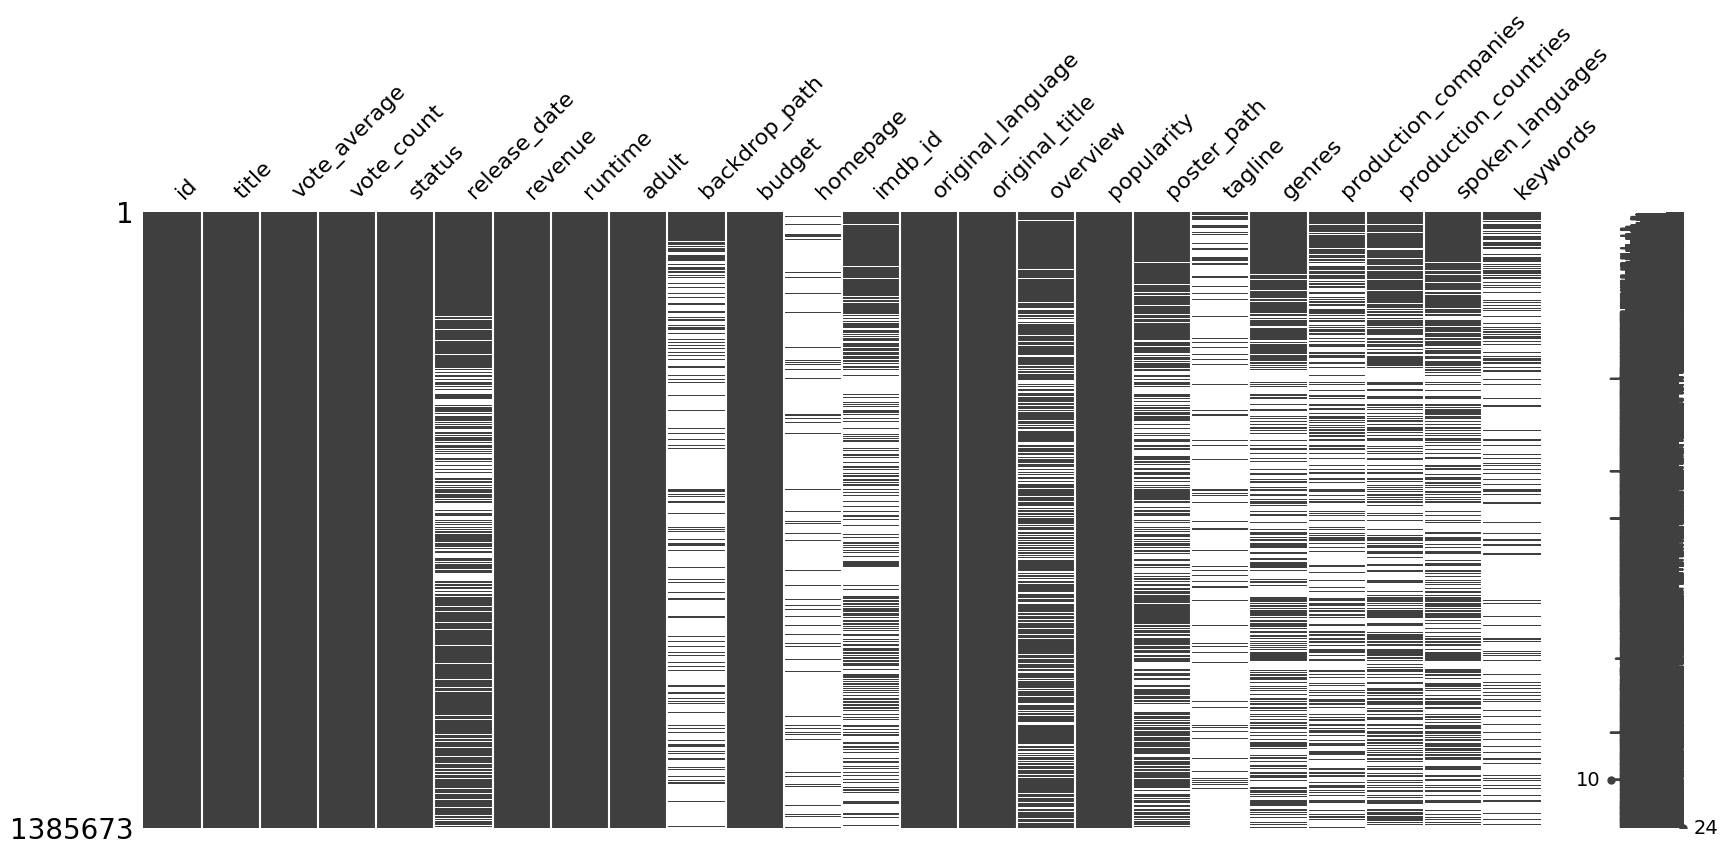

In [96]:
# Matriz de valores faltantes
msno.matrix(df, figsize=(20,8))

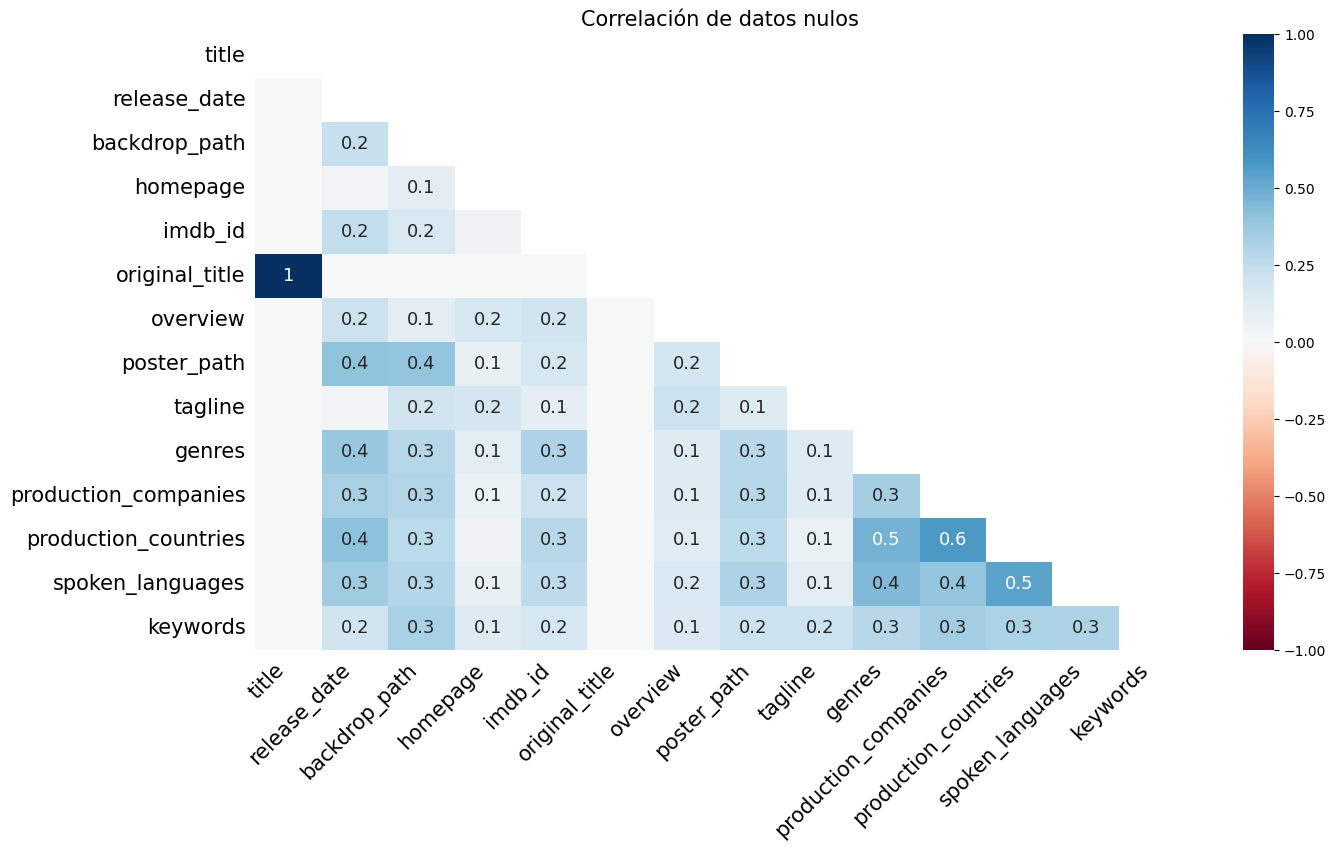

In [97]:
msno.heatmap(df, fontsize=15, figsize=(15,8))
plt.title("Correlación de datos nulos", fontsize=15)
plt.show()

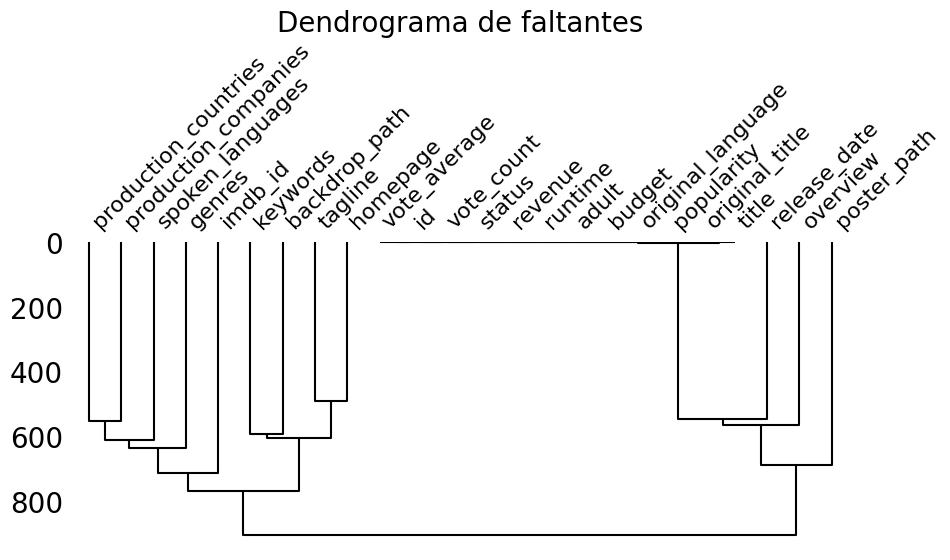

In [98]:
msno.dendrogram(df, figsize=(10,4))
plt.title('Dendrograma de faltantes', fontsize=20)
plt.show()

## Exploramos variables categóricas

### vote_average

In [99]:
df['vote_average'].max()


np.float64(10.0)

In [100]:
df['vote_average'].min()

np.float64(0.0)

### vote_count

In [101]:
df['vote_count'].max()

np.int64(34495)

In [102]:
df['vote_count'].min()

np.int64(0)

### status

In [103]:
df['status'].unique()

array(['Released', 'Planned', 'In Production', 'Post Production',
       'Rumored', 'Canceled'], dtype=object)

### release_date

In [104]:
pd.to_datetime(df['release_date'], errors='coerce').max()

Timestamp('2099-12-31 00:00:00')

In [105]:
pd.to_datetime(df['release_date'], errors='coerce').min()

Timestamp('1800-01-01 00:00:00')

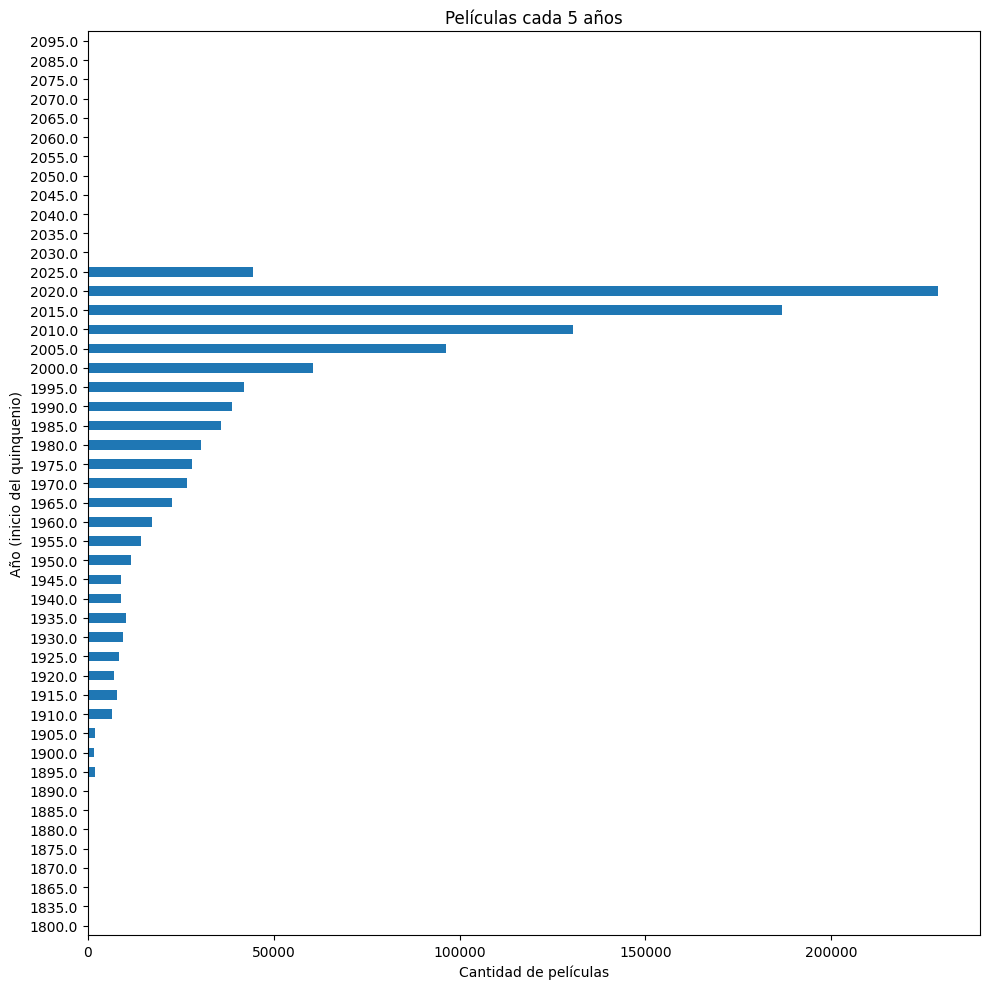

In [106]:
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year.dropna().astype(int)
df['quinquenio'] = (df['year'] // 5) * 5   # 1992→1990, 1997→1995, 2003→2000
peliculas_por_5_anos = df['quinquenio'].value_counts().sort_index()
peliculas_por_5_anos.plot(kind='barh', figsize=(10, 10))
plt.xlabel('Cantidad de películas')
plt.ylabel('Año (inicio del quinquenio)')
plt.title('Películas cada 5 años')
plt.tight_layout()
plt.show()

### revenue

In [107]:
df['revenue'].max()

np.int64(4999999999)

In [108]:
df['revenue'].min()

np.int64(-12)

### runtime

In [109]:
df['runtime'].max()

np.int64(14400)

In [110]:
df['runtime'].min()

np.int64(-28)

### adult

In [111]:
df['adult'].unique()

array([False,  True])

### backdrop_path

https://image.tmdb.org/t/p/w533_and_h300_face/@@image@@

### budget

In [112]:
df['budget'].max()

np.int64(999999999)

In [113]:
df['budget'].min()

np.int64(0)

### homepage


### imdb_id

### original_language

In [114]:
df['original_language'].unique()

array(['en', 'ko', 'fr', 'ja', 'it', 'es', 'pl', 'pt', 'hi', 'tr', 'da',
       'de', 'cn', 'id', 'zh', 'sv', 'el', 'ru', 'sr', 'fa', 'th', 'ar',
       'no', 'nb', 'fi', 'te', 'la', 'nl', 'hu', 'he', 'is', 'ro', 'gl',
       'uk', 'eu', 'et', 'bs', 'bn', 'xx', 'sh', 'km', 'cs', 'tn', 'ml',
       'mk', 'ga', 'hy', 'ku', 'ka', 'ta', 'kn', 'tl', 'vi', 'ca', 'dz',
       'sw', 'kk', 'wo', 'sk', 'lv', 'mi', 'bo', 'ps', 'mn', 'lt', 'ur',
       'sl', 'sc', 'af', 'hr', 'iu', 'se', 'ms', 'bm', 'mr', 'bg', 'lo',
       'am', 'cy', 'xh', 'yi', 'qu', 'yo', 'sq', 'pa', 'eo', 'gu', 'zu',
       'st', 'ne', 'ak', 'mt', 'rw', 'as', 'ln', 'ay', 'si', 'mo', 'ff',
       'so', 'ky', 'kl', 'ik', 'az', 'ab', 'jv', 'li', 'sn', 'fo', 'my',
       'su', 'tg', 'ks', 'lb', 'ht', 'rm', 'ha', 'tk', 'sa', 'sm', 'fy',
       'ny', 'bi', 'om', 'or', 'gd', 'be', 'mg', 'uz', 'cr', 'co', 'mh',
       'nn', 'gn', 'ia', 'tw', 'nv', 'ig', 'tt', 'ug', 'os', 'dv', 'ba',
       'oc', 'nd', 'ty', 'kw', 'sg', 'ie', 'sd', 'f

### original_title

### popularity

In [115]:
df['popularity'].max()

np.float64(2994.357)

In [116]:
df['popularity'].min()

np.float64(0.0)

### poster_path

https://image.tmdb.org/t/p/w533_and_h300_face/@@image@@

### tagline

In [117]:
df['tagline'].head()

0                 Your mind is the scene of the crime.
1    Mankind was born on Earth. It was never meant ...
2                    Welcome to a world without rules.
3                          Enter the world of Pandora.
4                              Some assembly required.
Name: tagline, dtype: object

### genres

In [118]:
sorted(
    df['genres']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

['Action',
 'Adventure',
 'Animation',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Family',
 'Fantasy',
 'History',
 'Horror',
 'Music',
 'Mystery',
 'Romance',
 'Science Fiction',
 'TV Movie',
 'Thriller',
 'War',
 'Western']

### production_companies

In [119]:
production_companies = sorted(
    df['production_companies']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

production_companies

['',
 '"A ME AND YOU MOTION PICTURE"',
 '"Creo" of M. Bystritsky',
 '"DIA" Productions GmbH & Co. KG',
 '"Dann Moss Entertainment',
 '"En TeorÃ\xada" Producciones',
 '"Film Company "Karbush"',
 '"Filma" Shareholders\' Association',
 '"G" P.C. S.A.',
 '"GREEN" Productions',
 '"Hanochi" Film Partners',
 '"Haruka\'s Pottery" Film Partners',
 '"Hypnosis Mic - Division Rap Battle" Rule the Stage Production Committee',
 '"I Used To Fuck People Like You In Prison" Records',
 '"It Goes to 11" Productions',
 '"Just The Filter" Productions',
 '"M" Films',
 '"MIYAGINO" Film Partners',
 '"Mega" Marbella Entertainment Groups & Artists',
 '"N" Film Studio',
 '"Shine kino" studio',
 '"Srcem za djecu" Sarajevo',
 '"Step" Ltd KinoÅ\x9firkÉ\x99ti',
 '"Swaying Mariko" Film Production Committee',
 '"TOKYO Ainu" Film Production Committee',
 '"Virtuoz" TRK',
 '"Weathering With You" Film Partners',
 '"Yeni Film" Film Company',
 '"unknown" estudios',
 '"á\x83¥á\x83\x90á\x83\xa0á\x83\x97á\x83£á\x83\x9aá\x83\x9

In [120]:
len(production_companies)

186311

### production_countries

In [121]:
production_countries = sorted(
    df['production_countries']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

production_countries

['Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antarctica',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Bouvet Island',
 'Brazil',
 'British Indian Ocean Territory',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burma',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Christmas Island',
 'Cocos  Islands',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Costa Rica',
 "Cote D'Ivoire",
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czech Republic',
 'Czechoslovakia',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'East Germany',
 'East Timor',
 'Ecuador',
 'Egypt',
 'El Salvador

In [122]:
len(production_countries)

250

### spoken_languages

In [123]:
spoken_languages = sorted(
    df['spoken_languages']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

spoken_languages

['Abkhazian',
 'Afar',
 'Afrikaans',
 'Akan',
 'Albanian',
 'Amharic',
 'Arabic',
 'Aragonese',
 'Armenian',
 'Assamese',
 'Avaric',
 'Avestan',
 'Aymara',
 'Azerbaijani',
 'Bambara',
 'Bashkir',
 'Basque',
 'Belarusian',
 'Bengali',
 'Bislama',
 'Bosnian',
 'Breton',
 'Bulgarian',
 'Burmese',
 'Cantonese',
 'Catalan',
 'Chamorro',
 'Chechen',
 'Chichewa; Nyanja',
 'Chuvash',
 'Cornish',
 'Corsican',
 'Cree',
 'Croatian',
 'Czech',
 'Danish',
 'Divehi',
 'Dutch',
 'Dzongkha',
 'English',
 'Esperanto',
 'Estonian',
 'Ewe',
 'Faroese',
 'Fijian',
 'Finnish',
 'French',
 'Frisian',
 'Fulah',
 'Gaelic',
 'Galician',
 'Ganda',
 'Georgian',
 'German',
 'Greek',
 'Guarani',
 'Gujarati',
 'Haitian; Haitian Creole',
 'Hausa',
 'Hebrew',
 'Herero',
 'Hindi',
 'Hiri Motu',
 'Hungarian',
 'Icelandic',
 'Ido',
 'Igbo',
 'Indonesian',
 'Interlingua',
 'Interlingue',
 'Inuktitut',
 'Inupiaq',
 'Irish',
 'Italian',
 'Japanese',
 'Javanese',
 'Kalaallisut',
 'Kannada',
 'Kanuri',
 'Kashmiri',
 'Kazakh'

In [124]:
len(spoken_languages)

186

### keywords

In [125]:
keywords = sorted(
    df['keywords']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

keywords

['',
 '"me escanee el ojo',
 '"on the "brink of death"',
 '"on the brink of death"',
 '"robin hood" thieves',
 '"spider" john koerner',
 '"the dunce" series',
 '"where every choice changes your life."',
 '"à¶\x85à¶´à·\x92 à¶¶à¶½à·\x8aà¶½à·\x9d à·\x80à¶\x9cà·\x9a à¶\x9aà·\x8fà¶\x9cà¶±à·\x8aà¶±à·\x80à·\x8f à·\x83à¶»à·\x8a à¶´à·\x9cà¶©à·\x92 à¶¸à·\x83à·\x8aà¶\x9aà¶§à·\x8aà¶§à¶\x9aà¶§"',
 '#',
 '#bobimovie',
 '#brazilianblackmusic',
 '#comedy #gangsters #fantasy #lawofattraction #funny #release #uk #usa #love #evil #guns #humor #anotherexcellentday #guyritchie #snatch #quentintarantino #trainspotting',
 '#deliveranceshortfilm',
 '#finalclash',
 '#lauterwerden',
 '#likeme',
 '#loveoverwealth',
 '#milamovie',
 '#mute',
 '#nghesieude',
 '#nsd',
 '#parisfashion #sexygirlstyle #parisstreetstyle #frenchfashionvibes #gothfashion #y2kstyle #darkaesthetic #streetwearvibes #edgystyle #artsylook',
 '#raffyhdz',
 '#tahilsumkan',
 '#terremoto',
 '#tipmuskan',
 '#tubeclash',
 '#walktalk',
 '#yeahhh',
 "

In [126]:
len(keywords)

68127